# Pandas API en Spark

## Importación de las librerías Pandas y Pandas API Spark

In [1]:
import pandas as pd
import numpy as np
import pyspark.pandas as ps
from pyspark.sql import SparkSession

/Users/ale/Proyectos/envs/pyspark_env/lib/python3.11/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


## Creación de objetos

Creación de una serie de pandas en Spark, recibiendo una lista de valores

In [2]:
s = ps.Series([1,3,5,np.NaN, 6, 8])
s

25/07/17 14:51:42 WARN Utils: Your hostname, MacBook-Pro-de-ale.local resolves to a loopback address: 127.0.0.1; using 192.168.100.14 instead (on interface en0)
25/07/17 14:51:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/17 14:51:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

Creación de un DataFrame de pandas en Spark, recibiendo un diccionario

In [3]:
psdf = ps.DataFrame(
    {
        'a': [1,2,3,4,5,6],
        'b': [100,200,300,400,500,600],
        'c': ['one', 'two', 'three', 'four', 'five', 'six']
    },
    index=[10,20,30,40,50,60]
)
psdf

,a,b,c
10,1,100,one
20,2,200,two
30,3,300,three
40,4,400,four
50,5,500,five
60,6,600,six


Creación de un DataFrame recibiendo una matriz numpy, con un índice de fecha, hora y columna etiquetada

In [4]:
dates = pd.date_range('20250101', periods=6)
dates

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06'],
              dtype='datetime64[ns]', freq='D')

In [5]:
pdf = pd.DataFrame(np.random.randn(6,4), index=dates, columns=list('ABCD'))
pdf

,A,B,C,D
2025-01-01,0.629831,-1.195034,0.346376,-1.205803
2025-01-02,-0.430566,-0.858373,-1.511585,-0.006779
2025-01-03,-1.141238,-0.073227,-0.528447,1.845960
2025-01-04,-0.802815,-1.122192,-1.367837,1.029921
2025-01-05,1.237999,2.076389,-1.051875,0.467801
2025-01-06,0.600041,0.872117,1.604158,0.867929


La conversión del DataFrame de pandas a un DataFrme de pandas Spark es muy fácil y se comporta igual

In [6]:
psdf = ps.from_pandas(pdf)
psdf

,A,B,C,D
2025-01-01,0.629831,-1.195034,0.346376,-1.205803
2025-01-02,-0.430566,-0.858373,-1.511585,-0.006779
2025-01-03,-1.141238,-0.073227,-0.528447,1.845960
2025-01-04,-0.802815,-1.122192,-1.367837,1.029921
2025-01-05,1.237999,2.076389,-1.051875,0.467801
2025-01-06,0.600041,0.872117,1.604158,0.867929


In [7]:
type(psdf)

pyspark.pandas.frame.DataFrame

Creación de un Spark DataFrame a partir de un pandas DataFrame

In [8]:
spark = SparkSession.builder.getOrCreate()

In [9]:
sdf = spark.createDataFrame(pdf)

In [10]:
sdf.show()

+-------------------+-------------------+-------------------+--------------------+
|                  A|                  B|                  C|                   D|
+-------------------+-------------------+-------------------+--------------------+
| 0.6298310076269985|-1.1950344047779322|  0.346375863668871|    -1.2058029906606|
|-0.4305661071521784|-0.8583731907107096|-1.5115845765706315|-0.00677946795881...|
|-1.1412382285528522|-0.0732265794038324|-0.5284473788031115|  1.8459596029728769|
|-0.8028154902068385|-1.1221919787991799|-1.3678368980344393|  1.0299213377085998|
| 1.2379991821749246| 2.0763889293377433| -1.051874851032325|  0.4678009314954327|
| 0.6000411214078627| 0.8721166271706842| 1.6041582350817931|  0.8679292920563543|
+-------------------+-------------------+-------------------+--------------------+



Creación de un Spark DataFrame
Los datos de un Spark DataFrame no conservan el orden natural, es posible configurarlo con la opción compute_ordered_head pero dicha orden genera una sobrecarga de rendimiento.

In [11]:
psdf = sdf.pandas_api()
psdf

,A,B,C,D
0,0.629831,-1.195034,0.346376,-1.205803
1,-0.430566,-0.858373,-1.511585,-0.006779
2,-1.141238,-0.073227,-0.528447,1.845960
3,-0.802815,-1.122192,-1.367837,1.029921
4,1.237999,2.076389,-1.051875,0.467801
5,0.600041,0.872117,1.604158,0.867929


In [12]:
psdf.head()

,A,B,C,D
0,0.629831,-1.195034,0.346376,-1.205803
1,-0.430566,-0.858373,-1.511585,-0.006779
2,-1.141238,-0.073227,-0.528447,1.845960
3,-0.802815,-1.122192,-1.367837,1.029921
4,1.237999,2.076389,-1.051875,0.467801


Visualización del índice, las columnas y los datos numpy

In [13]:
psdf.index

Index([0, 1, 2, 3, 4, 5], dtype='int64')

In [14]:
psdf.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

In [15]:
psdf.to_numpy()

/Users/ale/Proyectos/envs/pyspark_env/lib/python3.11/site-packages/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


array([[ 0.62983101, -1.1950344 ,  0.34637586, -1.20580299],
       [-0.43056611, -0.85837319, -1.51158458, -0.00677947],
       [-1.14123823, -0.07322658, -0.52844738,  1.8459596 ],
       [-0.80281549, -1.12219198, -1.3678369 ,  1.02992134],
       [ 1.23799918,  2.07638893, -1.05187485,  0.46780093],
       [ 0.60004112,  0.87211663,  1.60415824,  0.86792929]])

Resumen estadístico rápido de los datos

In [16]:
psdf.describe()

25/07/17 14:53:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,0.015542,-0.050053,-0.418202,0.499838
std,0.940240,1.302807,1.198792,1.038790
min,-1.141238,-1.195034,-1.511585,-1.205803
25%,-0.802815,-1.122192,-1.367837,-0.006779
50%,-0.430566,-0.858373,-1.051875,0.467801
75%,0.629831,0.872117,0.346376,1.029921
max,1.237999,2.076389,1.604158,1.845960


Transpuesta de los datos

In [17]:
psdf.T

,0,1,2,3,4,5
A,0.629831,-0.430566,-1.141238,-0.802815,1.237999,0.600041
B,-1.195034,-0.858373,-0.073227,-1.122192,2.076389,0.872117
C,0.346376,-1.511585,-0.528447,-1.367837,-1.051875,1.604158
D,-1.205803,-0.006779,1.845960,1.029921,0.467801,0.867929


Ordenar por su índice

In [18]:
psdf.sort_index(ascending=False)

,A,B,C,D
5,0.600041,0.872117,1.604158,0.867929
4,1.237999,2.076389,-1.051875,0.467801
3,-0.802815,-1.122192,-1.367837,1.029921
2,-1.141238,-0.073227,-0.528447,1.845960
1,-0.430566,-0.858373,-1.511585,-0.006779
0,0.629831,-1.195034,0.346376,-1.205803


Ordenar por valor

In [19]:
psdf.sort_values(by='B')

,A,B,C,D
0,0.629831,-1.195034,0.346376,-1.205803
3,-0.802815,-1.122192,-1.367837,1.029921
1,-0.430566,-0.858373,-1.511585,-0.006779
2,-1.141238,-0.073227,-0.528447,1.845960
5,0.600041,0.872117,1.604158,0.867929
4,1.237999,2.076389,-1.051875,0.467801


## Datos faltantes

Pandas API Spark utiliza el valor np.nan para represenar datos faltantes

In [20]:
pdf_one = pdf.reindex(index=dates[0:4], columns=list(pdf.columns) + ['E'])

In [21]:
pdf_one.loc[dates[0]:dates[1], 'E'] = 1

In [22]:
psdf_one = ps.from_pandas(pdf_one)
psdf_one

,A,B,C,D,E
2025-01-01,0.629831,-1.195034,0.346376,-1.205803,1.0
2025-01-02,-0.430566,-0.858373,-1.511585,-0.006779,1.0
2025-01-03,-1.141238,-0.073227,-0.528447,1.845960,NaN
2025-01-04,-0.802815,-1.122192,-1.367837,1.029921,NaN


Eliminar datos faltantes

In [23]:
psdf_one.dropna(how='any')

,A,B,C,D,E
2025-01-01,0.629831,-1.195034,0.346376,-1.205803,1.0
2025-01-02,-0.430566,-0.858373,-1.511585,-0.006779,1.0


Rellenar datos faltantes

In [24]:
psdf_one.fillna(value=5)

,A,B,C,D,E
2025-01-01,0.629831,-1.195034,0.346376,-1.205803,1.0
2025-01-02,-0.430566,-0.858373,-1.511585,-0.006779,1.0
2025-01-03,-1.141238,-0.073227,-0.528447,1.845960,5.0
2025-01-04,-0.802815,-1.122192,-1.367837,1.029921,5.0


## Operaciones

### Estadísticas

Realiza estadística descriptiva

In [25]:
psdf.mean()

A    0.015542
B   -0.050053
C   -0.418202
D    0.499838
dtype: float64

### Configuraciones de Spark

Es posible aplicar configuraciones como optimizaciones de Arrow para acelerar la conversión interna de panda

In [26]:
prev = spark.conf.get('spark.sql.execution.arrow.pyspark.enabled')
ps.set_option('compute.default_index_type', 'distributed')

import warnings
warnings.filterwarnings('ignore')

In [27]:
spark.conf.set('spark.sql.execution.arrow.pyspark.enable', True)
%timeit ps.range(300000).to_pandas()

1.55 s ± 90.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
spark.conf.set('spark.sql.execution.arrow.pyspark.enabled', False)
%timeit ps.range(300000).to_pandas()

1.4 s ± 64.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [29]:
ps.reset_option('compute.default_index_type')
spark.conf.set('spark.sql.execution.arrow.pyspark.enabled', prev)

### Agrupación

La opción group_by implica los siguientes pasos:
1. Dividir los datos en grupos según algún criterio
2. Aplicar una función a cada grupo de forma independiente
3. Combinar los resultados en una estructura de datos

In [30]:
psdf = ps.DataFrame(
    {
        'A': ['foo', 'bar', 'foo', 'bar', 'foo', 'bar', 'foo', 'foo'],
        'B': ['one', 'one', 'two', 'three', 'two', 'two', 'one', 'three'],
        'C': np.random.randn(8),
        'D': np.random.randn(8)
    }
)
psdf

,A,B,C,D
0,foo,one,1.299120,-2.283031
1,bar,one,-0.076835,0.604610
2,foo,two,0.300495,0.569773
3,bar,three,-1.277293,-0.627628
4,foo,two,-0.187115,0.091597
5,bar,two,-0.447357,2.772655
6,foo,one,-0.527420,-0.797909
7,foo,three,1.879217,-0.730032


Aplicar la agrupación y la función suma a los grupos resultantes

In [31]:
psdf.groupby('A').sum()

,C,D
A,,
foo,2.764297,-3.149603
bar,-1.801485,2.749637


La agrupación por múltiples columnas forma un índice jerárquico

In [32]:
psdf.groupby(['A','B']).sum()

C         D
A   B                        
foo one    0.771700 -3.080940
bar one   -0.076835  0.604610
foo two    0.113380  0.661370
bar three -1.277293 -0.627628
    two   -0.447357  2.772655
foo three  1.879217 -0.730032

### Ploting

25/07/17 15:09:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:09:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:09:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:09:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:09:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


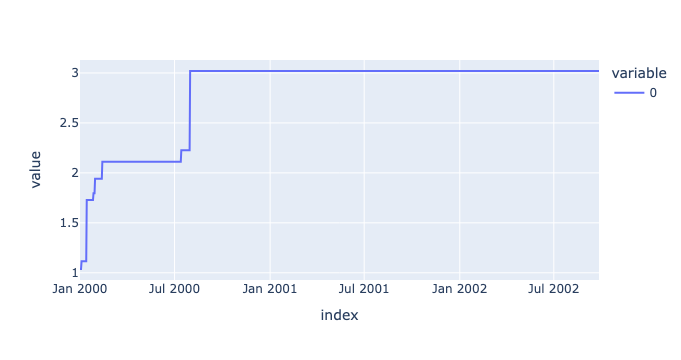

In [33]:
pser = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000))
psser = ps.Series(pser)
psser = psser.cummax()
psser.plot()

25/07/17 15:11:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:11:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:11:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:11:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:11:58 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


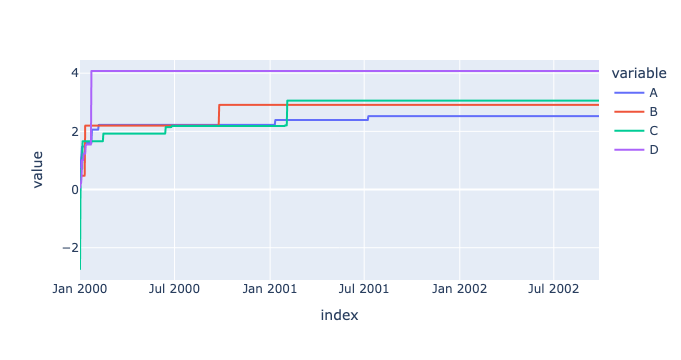

In [35]:
pdf = pd.DataFrame(np.random.randn(1000, 4), index=pser.index, columns=['A','B','C','D'])
psdf = ps.from_pandas(pdf)
psdf = psdf.cummax()
psdf.plot()

## Obtener datos de entrada y salida

### Formato CSV

Crear y guardar un archivo en formato csv

In [38]:
psdf.to_csv('foo.csv')
ps.read_csv('foo.csv').head(10)

25/07/17 15:13:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:13:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:13:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:13:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:13:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,A,B,C,D
0,-0.142808,-1.448064,-2.731660,0.062910
1,-0.142808,0.473824,0.136273,0.209738
2,1.067640,0.473824,0.707953,0.209738
3,1.239734,0.473824,0.707953,0.445492
4,1.481047,0.473824,0.707953,1.006607
5,1.481047,0.473824,1.661339,1.006607
6,1.481047,0.473824,1.661339,1.006607
7,1.481047,0.473824,1.661339,1.233532
8,1.481047,0.473824,1.661339,1.233532
9,1.481047,0.473824,1.661339,1.233532


### Parquet

Parquet es un formato eficiente y compacto que permite leer y escribir con mayor rapidez.
Crear y guardar un archivo en formato parquet

In [40]:
psdf.to_parquet('bar.parquet')
ps.read_parquet('bar.parquet').head(10)

25/07/17 15:14:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:14:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:14:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:14:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:14:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,A,B,C,D
0,-0.142808,-1.448064,-2.731660,0.062910
1,-0.142808,0.473824,0.136273,0.209738
2,1.067640,0.473824,0.707953,0.209738
3,1.239734,0.473824,0.707953,0.445492
4,1.481047,0.473824,0.707953,1.006607
5,1.481047,0.473824,1.661339,1.006607
6,1.481047,0.473824,1.661339,1.006607
7,1.481047,0.473824,1.661339,1.233532
8,1.481047,0.473824,1.661339,1.233532
9,1.481047,0.473824,1.661339,1.233532


### Spark IO

Pandas API Spark es compatible con diversas funetes de datos de Spark como ORC y una fuente de datos externa.

In [41]:
psdf.spark.to_spark_io('zoo.orc', format='orc')
ps.read_spark_io('zoo.orc', format='orc').head(10)

25/07/17 15:16:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:16:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:16:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:16:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/07/17 15:16:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
                                                                                

,A,B,C,D
0,-0.142808,-1.448064,-2.731660,0.062910
1,-0.142808,0.473824,0.136273,0.209738
2,1.067640,0.473824,0.707953,0.209738
3,1.239734,0.473824,0.707953,0.445492
4,1.481047,0.473824,0.707953,1.006607
5,1.481047,0.473824,1.661339,1.006607
6,1.481047,0.473824,1.661339,1.006607
7,1.481047,0.473824,1.661339,1.233532
8,1.481047,0.473824,1.661339,1.233532
9,1.481047,0.473824,1.661339,1.233532
